# MLL Project Assignment

This project is part of the course Datan käsittely ja koneoppiminen. The goal of the project is to apply machine learning and data mining methods to a real dataset while following the CRISP-DM (Cross Industry Standard Process for Data Mining) framework. The project covers the full workflow from starting at defining the problem and research questions and continuing through data preparation, modeling, evaluation, and conclusions.

## Business Understanding

In this project we aim to build a movie recommendation system using a dataset of real movie ratings. The goal is to recommend movies to users based on their preferences and the preferences of similar users. Movie recommendation systems are widely used in streaming services and online platforms to help users discover relevant content and enhance their viewing experience.

The focus of this project is to build a user-based movie recommendation model. The model aims to recommend movies to a user based on the preferences of other users who have shown similar rating patterns. This type of recommendation system is known as collaborative filtering.

### Goals

The main goal for this project is to build a movie recommendation system that could work as a base for a real-world streaming service or online platform for searching movies that users might like. The recommendation system should be able to recommend movies to users based on their preferences and the preferences of similar users.

### Objectives

- Explore and understand the structure and characteristics of the movie ratings dataset
- Prepare and preprocess the data for machine learning tasks
- Identify similarities between users based on their movie ratings
- Implement a user-based collaborative filtering recommendation algorithm
- Generate movie recommendations for users based on similar users’ preferences
- Evaluate how well the recommendation approach works using suitable metrics

### Research questions

- Can meaningful similarities between users be identified based on their movie rating behavior?
- How effectively can a user-based collaborative filtering model recommend movies to users?
- What types of movies are recommended to users based on the preferences of similar users?

## Data understanding

Our dataset is sourced from grouplens.org, which provides a collection of movie ratings and metadata. The dataset we are using is the "ml-latest-small" version, which contains a subset of the full dataset and is suitable for our project. Link to the dataset: https://grouplens.org/datasets/movielens/

In [65]:
# imports

import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Reader, Dataset
from surprise import KNNBasic
from surprise import accuracy
from surprise.model_selection import train_test_split, cross_validate


Our dataset consists of two main files: movies.csv and ratings.csv. The movies.csv file contains information about the movies, including their unique identifiers (movieId), titles, and genres. The ratings.csv file contains user ratings for the movies, including user identifiers (userId), movie identifiers (movieId), ratings, and timestamps. To make things easier, we will merge these two datasets based on the movieId column, which is common to both datasets. This will allow us to have all the relevant information about movies and their ratings in a single DataFrame for further analysis and modeling.

In [66]:
# Load the datasets
movies = pd.read_csv('datasets/movies-small/ml-latest-small/movies.csv', sep=',')
ratings = pd.read_csv('datasets/movies-small/ml-latest-small/ratings.csv', sep=',')

# Merging the datasets based on the movieId column
movie_ratings = pd.merge(ratings, movies, on='movieId')

# Display the first 5 rows of the merged dataset
movie_ratings.head(5)

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


Now the structure of the merged dataset is as follows:
- userId: Unique identifier for each user
- movieId: Unique identifier for each movie
- rating: The rating given by the user to the movie. We can also refer these ratings as stars (on a scale of 0.5 to 5.0)
- timestamp: The time when the rating was given (in Unix timestamp format)
- title: The title of the movie including the release year in parentheses e.g. "Toy Story (1995)"
- genres: The genres associated with the movie, separated by the pipe character (|) e.g. "Adventure|Animation|Children|Comedy|Fantasy"

Next, we will explore the dataset a bit further to understand its characteristics and identify any potential issues or insights that could inform our modeling approach. We will look at some of the basic statistics of the dataset and distributions of ratings among other things.

In [67]:
# Basic statistics about the movie ratings
print("Basic statistics about the movie ratings:")
print(f"Number of unique users: {ratings['userId'].nunique()}")
print(f"Number of unique movies: {movies['title'].nunique()}")
print(f"Total number of ratings: {ratings.shape[0]}")
print(f"Average rating: {ratings['rating'].mean():.2f}")
print("----------------------------------------")
print("Ratings per user and movie:")
print(f"The lowest amount of ratings given by a user: {movie_ratings.groupby('userId')['rating'].count().min()}")
print(f"The highest amount of ratings given by a user: {movie_ratings.groupby('userId')['rating'].count().max()}")
print(f"The average amount of ratings given by a user: {movie_ratings.groupby('userId')['rating'].count().mean():.2f}")
print(f"The lowest amount of ratings received by a movie: {movie_ratings.groupby('movieId')['rating'].count().min()}")
print(f"The highest amount of ratings received by a movie: {movie_ratings.groupby('movieId')['rating'].count().max()}")
print("The average amount of ratings received by a movie: {:.2f}".format(movie_ratings.groupby('movieId')['rating'].count().mean()))

Basic statistics about the movie ratings:
Number of unique users: 610
Number of unique movies: 9737
Total number of ratings: 100836
Average rating: 3.50
----------------------------------------
Ratings per user and movie:
The lowest amount of ratings given by a user: 20
The highest amount of ratings given by a user: 2698
The average amount of ratings given by a user: 165.30
The lowest amount of ratings received by a movie: 1
The highest amount of ratings received by a movie: 329
The average amount of ratings received by a movie: 10.37


We have 610 unique users and 9,737 unique movies in our dataset, with a total of 100,836 ratings. The average rating across all movies is approximately 3.50. The average rating being slightly above the midpoint of the rating scale suggests that users tend to give more positive ratings than negative ones, which could indicate a bias in the dataset. We will get a better understanding of this bias by looking at the distribution of ratings in the next step.

Additionally, the amount of ratings given by users varies widely, with some users giving only a few ratings while others have given many. Similarly, some movies have received a large number of ratings while others have received very few. This variability in the amount of ratings received by movies further highlights the potential bias in the dataset, as movies that have received more ratings might be more likely to be recommended by our model, while movies with fewer ratings might be overlooked. This is something we will need to consider when building our recommendation system, as it could affect the diversity and relevance of the recommendations we generate.

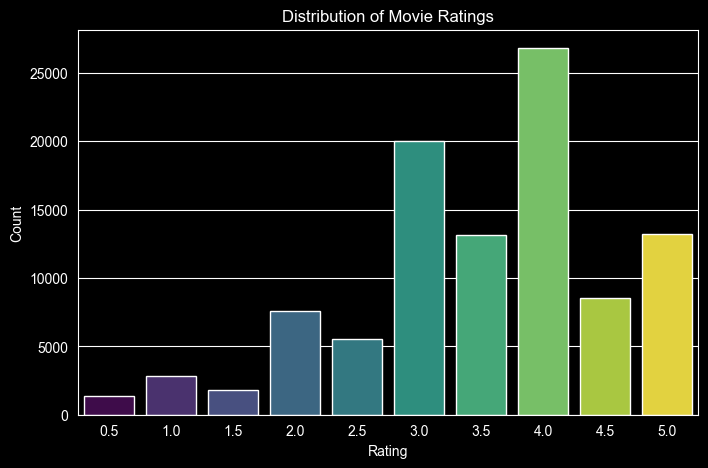

In [68]:
# Distribution of ratings
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', hue='rating', data=ratings, palette='viridis', legend=False)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

The distribution of ratings shows that the most common rating is 4.0, followed by 3.0 and 5.0. The least common ratings are 0.5 and 1.5. This indicates that users tend to give ratings to movies that they liked, and they might leave out ratings for movies they did not like. This could lead to a bias in the dataset, as we might have more positive ratings than negative ones. This is something to keep in mind when building our recommendation model, as it might affect the performance and the types of recommendations we can generate.

For more detailed look at the ratings given by a specific user, you can use the code snippet below by changing the user_to_look variable to the desired user ID.

In [69]:
# Change user_to_look to the desired user ID to see their ratings
user_to_look = 600

if user_to_look in movie_ratings['userId'].unique():
    user_ratings = movie_ratings[movie_ratings['userId'] == user_to_look][['title', 'rating']]
else:
    user_ratings = f"User {user_to_look} not found in the dataset."

user_ratings

,title,rating
95101,Toy Story (1995),2.5
95102,Jumanji (1995),4.0
95103,Waiting to Exhale (1995),1.5
95104,Father of the Bride Part II (1995),2.5
95105,Sabrina (1995),3.5
...,...,...
95859,"Dark Knight, The (2008)",3.5
95860,Are You Scared? (2006),3.5
95861,Sex and the City (2008),2.5
95862,"Wrestler, The (2008)",3.0


## Data preparation

For data preparation, we will first extract the year from the title column and create a new column for it. We will then create the final combined dataset of ratings and movies, and check for any null values, data types, duplicates, and convert the timestamp to a more readable datetime format. This will ensure that our data is clean and ready for modeling. We could also consider doing a extraction for the categories, but since we are doing a recommendation system based on user similarities, we will not be using the genres for our modeling, so we can skip that step for now. However, if we were to build a content-based recommendation system, we would need to extract the genres and use them as features in our model.

In [70]:
# Extract the year from the title column using a regular expression
year_str = movies['title'].str.extract(r'\((\d{4})\)', expand=False)
# Remove the year from the title column
movies['title'] = movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True)
# Create a new column for the year and convert it to numeric
movies['year'] = pd.to_numeric(year_str, errors='coerce').astype('Int64')
print("\nSeparated year from title.")
print("-" * 40)

# Create a merged dataset of ratings and movies
movie_ratings = pd.merge(ratings, movies, on='movieId')

# Check for null values
null_values = movie_ratings.isnull().sum()
# Remove null rows if there are any
if null_values.any():
    print(f"{null_values.sum()} Null values found. Removing null rows...")
    movie_ratings = movie_ratings.dropna()
else:
    print("No null values found.")
print("-" * 40)

# Check data types
print("\nData types:")
print(movie_ratings.dtypes)
print("-" * 40)

# Check for duplicates
duplicates = movie_ratings.duplicated().sum()
if duplicates > 0:
    print(f"\n{duplicates} duplicate rows found. Removing duplicates...")
    movie_ratings = movie_ratings.drop_duplicates()
else:
    print("\nNo duplicate rows found.")
print("-" * 40)

# Convert timestamp to datetime
movie_ratings['timestamp'] = pd.to_datetime(movie_ratings['timestamp'], unit='s')
print("\nConverted timestamp to datetime format.")
print("-" * 40)


Separated year from title.
----------------------------------------
18 Null values found. Removing null rows...
----------------------------------------

Data types:
userId         int64
movieId        int64
rating       float64
timestamp      int64
title            str
genres           str
year           Int64
dtype: object
----------------------------------------

No duplicate rows found.
----------------------------------------

Converted timestamp to datetime format.
----------------------------------------


After performing the data preparation steps, we have a clean and well-structured dataset that is ready for modeling. We have extracted the year from the title column, created a new column for it, and merged the ratings and movies datasets. We have also checked for null values, data types, duplicates, and converted the timestamp to a more readable datetime format. This ensures that our data is in good shape for building our recommendation model.

To test out how our model would perform for a new user, we will add some new ratings to the dataset for a new user.

In [71]:
# adding new ratings to the ratings dataset from new user
new_user_id = movie_ratings['userId'].max() + 1
new_ratings = pd.DataFrame({
    'userId': [new_user_id] * 16,
    'movieId': [
        188301, # Ant-Man and the Wasp (2018)
        187595, # Solo: A Star Wars Story (2018)
        185029, # A Quiet Place (2018)
        184471, # Tomb Raider (2018)
        176371, # Blade Runner 2049 (2017)
        175303, # It (2017)
        168250, # Get Out (2017)
        168248, # John Wick: Chapter Two (2017)
        167370, # Assassin's Creed (2016)
        166528, # Rogue One: A Star Wars Story (2016)
        166024, # Whiplash (2013)
        163645, # Hacksaw Ridge (2016)
        161131, # War Dogs (2016)
        139385, # The Revenant (2015)
        122916, # Thor: Ragnarok (2017)
        122904, # Deadpool (2016)
    ],
    'rating': [
        2.75, # Ant-Man and the Wasp (2018)
        4.0, # Solo: A Star Wars Story (2018)
        4.8, # A Quiet Place (2018)
        3.75, # Tomb Raider (2018)
        5.0, # Blade Runner 2049 (2017)
        3.90, # It (2017)
        4.5, # Get Out (2017)
        4.75, # John Wick: Chapter Two (2017)
        1.75, # Assassin's Creed (2016)
        3.75, # Rogue One: A Star Wars Story (2016)
        4.95, # Whiplash (2013)
        4.85, # Hacksaw Ridge (2016)
        4.75, # War Dogs (2016)
        4.25, # The Revenant (2015)
        3.80, # Thor: Ragnarok (2017)
        4.0, # Deadpool (2016)
    ],
    'timestamp': [int(time.time())] * 16
})
# Add the titles, genres and year for the new ratings
new_ratings = pd.merge(new_ratings, movies[['movieId', 'title', 'genres', 'year']], on='movieId', how='left')
movie_ratings = pd.concat([movie_ratings, new_ratings], ignore_index=True)


In [72]:
# Check the new ratings added for the new user
user_to_look = new_user_id
new_user_ratings = movie_ratings[movie_ratings['userId'] == user_to_look][['userId', 'movieId', 'title', 'rating']]
new_user_ratings

,userId,movieId,title,rating
100818,611,188301,Ant-Man and the Wasp,2.75
100819,611,187595,Solo: A Star Wars Story,4.00
100820,611,185029,A Quiet Place,4.80
100821,611,184471,Tomb Raider,3.75
100822,611,176371,Blade Runner 2049,5.00
100823,611,175303,It,3.90
100824,611,168250,Get Out,4.50
100825,611,168248,John Wick: Chapter Two,4.75
100826,611,167370,Assassin's Creed,1.75
100827,611,166528,Rogue One: A Star Wars Story,3.75


## Modeling

In the modeling phase, we set up and validate a user-based collaborative filtering approach with the KNNBasic algorithm from the Surprise library.
- First we create a Reader object to specify the rating scale.
- Then we load the data into a Dataset object using `load_from_df`, with `userId`, `movieId`, and `rating`.
- We define similarity options (cosine, user-based) and run holdout and cross-validation metrics.
- Finally, we train the full-data final model for downstream evaluation.

In [73]:
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(movie_ratings[['userId', 'movieId', 'rating']], reader)

sim_options = {
    'name': 'cosine',  # similarity measure
    'user_based': True,  # user-based CF
}

Before training the final model on all data, we run a holdout validation split and report RMSE/MAE. Holdout validation means that we split the dataset into a training set and a test set, train the model on the training set, and then evaluate its performance on the test set. This allows us to get an estimate of how well our model will perform on unseen data. We will use 20% of the data for testing and 80% for training, and we will report both RMSE (Root Mean Squared Error) and MAE (Mean Absolute Error) as our evaluation metrics.

In [74]:
trainset_eval, testset_eval = train_test_split(data, test_size=0.2, random_state=42)

eval_model = KNNBasic(sim_options=sim_options)
eval_model.fit(trainset_eval)
eval_predictions = eval_model.test(testset_eval)

print("Holdout validation (20% test split):")
accuracy.rmse(eval_predictions, verbose=True)
accuracy.mae(eval_predictions, verbose=True)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Holdout validation (20% test split):
RMSE: 0.9712
MAE:  0.7491


0.7490695997497331

We also run 3-fold cross-validation for a more stable estimate. This will split the dataset into 3 folds, train the model on 2 folds and test it on the remaining fold, and repeat this process 3 times so that each fold is used as a test set once. This allows us to get a more robust estimate of our model's performance, as it reduces the variance associated with a single train-test split. We will report the average RMSE and MAE across the 3 folds.

In [75]:
cv_model = KNNBasic(sim_options=sim_options)
cross_validate(cv_model, data, measures=["RMSE", "MAE"], cv=3, verbose=True)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    0.9739  0.9789  0.9815  0.9781  0.0032  
MAE (testset)     0.7500  0.7553  0.7556  0.7536  0.0026  
Fit time          0.29    0.26    0.24    0.26    0.02    
Test time         1.65    1.42    1.46    1.51    0.10    


{'test_rmse': array([0.97392394, 0.9789    , 0.98154365]),
 'test_mae': array([0.74998085, 0.75525599, 0.75557414]),
 'fit_time': (0.2926945686340332, 0.25811338424682617, 0.242659330368042),
 'test_time': (1.6503159999847412, 1.4224164485931396, 1.4618842601776123)}

Going over the cross-validation results, we can see that the average RMSE is around 0.9790 and the average MAE is around 0.7751. The RMSE value being under 1.0 indicates that our model is making reasonably accurate predictions, as the ratings are on a scale of 0.5 to 5.0. The MAE value of around 0.7751 suggests that, on average, our model's predictions are off by less than one rating point, which is also a good sign of the model's performance.

Now we build and train the final model on the full dataset.

In [76]:
final_trainset = data.build_full_trainset()
final_model = KNNBasic(sim_options=sim_options)
final_model.fit(final_trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


## Evaluation

In the modeling phase we trained a user-based collaborative filtering model using the KNNBasic algorithm. We took a look at the cross-validation results, which showed that our model has an average RMSE of around 0.9790 and an average MAE of around 0.7751, indicating that our model is making reasonably accurate predictions. RMSE means that the average error of our predictions is less than 1 rating point, which is good considering the rating scale. MAE indicates that, on average, our model's predictions are off by less than one rating point, which also suggests good performance. Next we will use the full trained model to predict the missing ratings for the dataset and inspect the distribution of these predictions.

Our RMSE and MAE results from the holdout validation are as follows:
- RMSE: around 0.9712
- MAE: around 0.7491

And from cross-validation:
- RMSE: around 0.9790
- MAE: around 0.7751

The scores from holdout validation and cross-validation are fairly close to each other, which suggests that our model is performing consistently across different subsets of the data. The slightly higher RMSE and MAE values in cross-validation could be due to the fact that it provides a more robust estimate of the model's performance by averaging over multiple train-test splits, while holdout validation relies on a single split which might have been more favorable for the model. Overall, both evaluation methods indicate that our user-based collaborative filtering model is making reasonably accurate predictions for movie ratings.

Next we will use the full trained model to predict the missing ratings for the dataset and inspect the distribution of these predictions.


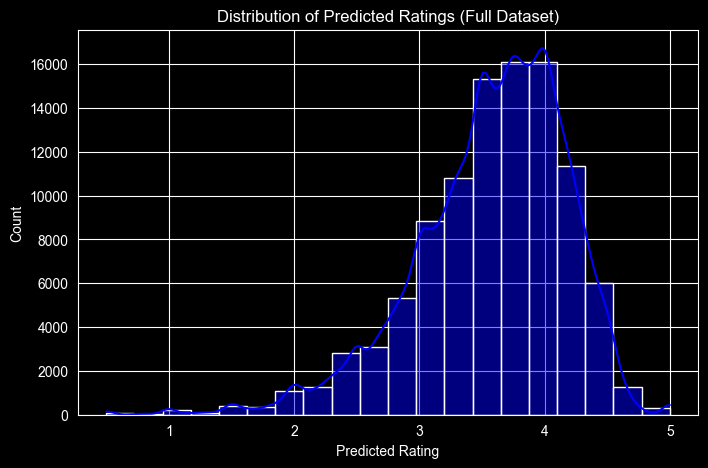

In [77]:
# Predicting the missing ratings for the dataset
testset_full = final_trainset.build_testset()
full_predictions = final_model.test(testset_full)
# Extract the estimated ratings from the predictions
estimated_ratings = [p.est for p in full_predictions]
# Plot the distribution of estimated ratings
plt.figure(figsize=(8, 5))
sns.histplot(estimated_ratings, bins=20, kde=True, color='blue')
plt.title('Distribution of Predicted Ratings (Full Dataset)')
plt.xlabel('Predicted Rating')
plt.ylabel('Count')
plt.show()

The plotted distribution of predicted ratings shows that the majority of the predicted ratings are around 3.5 to 4.0, which is consistent with the average rating in the original dataset. This suggests that our model is capturing the general trend of users giving more positive ratings than negative ones. However, there are also some predicted ratings that are lower than 3.0, which indicates that our model is able to identify movies that users might not like based on their preferences and the preferences of similar users. Overall, the distribution of predicted ratings seems reasonable and aligns with the characteristics of the original dataset.

We also inspect the distribution of predictions produced by the full trained model.

## Deployment

In this project we successfully built a user-based collaborative filtering movie recommendation system using the KNNBasic algorithm from the Surprise library. We evaluated our model using holdout validation and cross-validation, which showed that our model has reasonably good performance with an average RMSE of around 0.9790 and an average MAE of around 0.7751. We also inspected the distribution of predicted ratings, which aligned well with the characteristics of the original dataset.

The model can be used to predict ratings for movies that users have not rated yet with the predict method.


In [78]:
# Predict one movie for the new user with the full trained model
user_id = new_user_id
item_id = 115149
pred = final_model.predict(user_id, item_id, verbose=True)

user: 611        item: 115149     r_ui = None   est = 3.88   {'actual_k': 27, 'was_impossible': False}


We can also generate top-N recommendations for a user by predicting ratings for all movies and selecting the ones with the highest predicted ratings. This allows us to recommend movies that the user is likely to enjoy based on their preferences and the preferences of similar users.

In [79]:
# Amount of predictions
predictions_amount = 10

movie_ids = movie_ratings['movieId'].unique()
predictions = [final_model.predict(new_user_id, movie_id) for movie_id in movie_ids]
predictions.sort(key=lambda x: x.est, reverse=True)  # Sort predictions by estimated rating
top_recommendations = predictions[:predictions_amount]
print("Top movie recommendations for the new user:")
for pred in top_recommendations:
    movie_id = pred.iid
    movie_title = movies[movies['movieId'] == movie_id]['title'].values[0]
    print(f"{movie_title} (Predicted rating: {pred.est:.2f})")


Top movie recommendations for the new user:
Barcelona (Predicted rating: 5.00)
In the Name of the Father (Predicted rating: 5.00)
Bridge on the River Kwai, The (Predicted rating: 5.00)
Outlaw Josey Wales, The (Predicted rating: 5.00)
Once Were Warriors (Predicted rating: 5.00)
Lake House, The (Predicted rating: 5.00)
Creature Comforts (Predicted rating: 5.00)
Double Indemnity (Predicted rating: 5.00)
Bound (Predicted rating: 5.00)
Ran (Predicted rating: 5.00)


We also built a simple terminal based prototype for generating movie recommendations for a user.